In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random

In [235]:
df = pd.read_csv('datasets/mall-customers.csv')

In [236]:
print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 200
Columns: 7


In [237]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [238]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [239]:
df.duplicated().sum()

0

In [240]:
# Make a numerical copy of the dataset

df_num = df.select_dtypes(include='number').copy()

In [241]:
df_num.skew()

CustomerID                0.000000
Age                       0.485569
Annual Income (k$)        0.321843
Spending Score (1-100)   -0.047220
dtype: float64

**NOTE: No need to log transform**

## Section I: Preprocessing

In [242]:
# Extract X

X = df.iloc[:, :-1].copy()
X.drop('CustomerID', axis=1, inplace=True)

X.head()

,Gender,Age,Education,Marital Status,Annual Income (k$)
0,M,19,High School,Married,15
1,M,21,Graduate,Single,15
2,F,20,Graduate,Married,16
3,F,23,High School,Unknown,16
4,F,31,Uneducated,Married,17


In [243]:
# Rename 'Annual Income (k$)' to a more systematic name and transform X accordingly

X.rename(columns={'Annual Income (k$)':'AnnualIncome', 'Marital Status':'MaritalStatus', 'Education ': 'Education'}, inplace=True)
X['AnnualIncome'] *= 1000
X.head()

,Gender,Age,Education,MaritalStatus,AnnualIncome
0,M,19,High School,Married,15000
1,M,21,Graduate,Single,15000
2,F,20,Graduate,Married,16000
3,F,23,High School,Unknown,16000
4,F,31,Uneducated,Married,17000


In [244]:
# See the unique values for Education

temp = X['Education'].value_counts()

temp.head(10)

Education
Graduate         67
High School      40
Uneducated       31
Unknown          26
College          17
Doctorate        11
Post-Graduate     8
Name: count, dtype: int64

In [245]:
# Encode the datatset

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

one_hot_cols = ['Gender', 'MaritalStatus']

for col in one_hot_cols:
    ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
    transformed_cols = ohe.fit_transform(X[[col]])
    X.drop(col, axis=1, inplace=True)
    X = pd.concat([X, transformed_cols], axis=1)

oe = OrdinalEncoder(categories=[[
    'Uneducated', 'Unknown', 'High School', 
    'College', 'Graduate', 'Post-Graduate', 'Doctorate'
]])

X[['Education']] = oe.fit_transform(X[['Education']])

annual_income = X['AnnualIncome'].copy()
X.drop('AnnualIncome', axis=1, inplace=True)

X = pd.concat([X, annual_income], axis=1)

X.head()

,Age,Education,Gender_F,Gender_M,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Unknown,AnnualIncome
0,19,2.0,0.0,1.0,0.0,1.0,0.0,0.0,15000
1,21,4.0,0.0,1.0,0.0,0.0,1.0,0.0,15000
2,20,4.0,1.0,0.0,0.0,1.0,0.0,0.0,16000
3,23,2.0,1.0,0.0,0.0,0.0,0.0,1.0,16000
4,31,0.0,1.0,0.0,0.0,1.0,0.0,0.0,17000


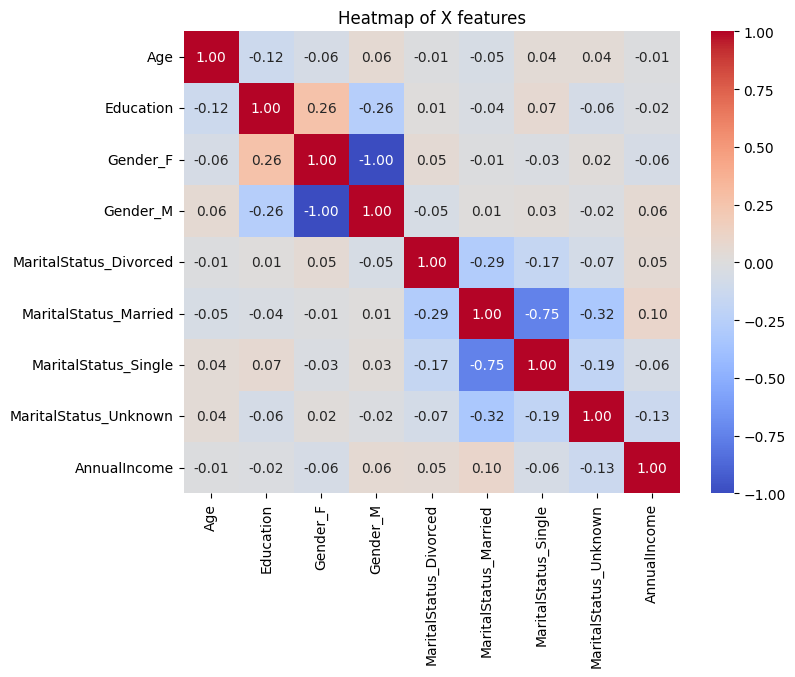

In [246]:
# Heatmap for possible colinearity

_corr = X.corr()

plt.figure(figsize=(8, 6))
plt.title('Heatmap of X features')
sns.heatmap(data=_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

**NOTE: There doesn't seem to be any major colinearities**

In [247]:
# Scale the dataset

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_scaled = ss.fit_transform(X)